# FR-guided sampling on a memorized sample, ambient space only

No projection, no Jacobian: `grad_{z_t} I(D_t(z_t))` via autograd through the denoiser
(`driver.make_autograd_guidance_fn`), `D=3072`. Energy: k-NN Fisher-Rao (`src/guidance/basic_fr.py`).

Three swept axes, seeds as the outermost loop:

- **`q_target`**: adaptive softmax temperature. At `D=3072` the posterior saturates
  (`q_max=1`, `||grad I||=0`) from about halfway through sampling, so scaling the gradient does
  nothing; holding `q_max` at a setpoint keeps it alive to `t=0`. `None` = untempered control.
- **`eta`**: guidance strength as a fraction of the sampler's step. Transfers across seeds, not
  across datasets (sinusoid needs `1.0`, CIFAR needs `0.1`).
- **`window_hi`**: where guidance stops. An unguided tail risks re-collapse but restores fidelity.

Per condition: denoising-steps panel, trajectory diagnostics, final `d1/d2` ratio, aggregated
across seeds at the end.

In [ ]:
import os, sys, time
import numpy as np
import torch
import matplotlib.pyplot as plt
from diffusers import UNet2DModel, DDPMScheduler

sys.path.insert(0, os.path.abspath("."))
sys.path.insert(0, os.path.abspath("../../src"))
from cifar10_data import load_cifar10
from assess_memorization_cifar10 import nearest_neighbor_d1_d2
from guidance import driver, basic_fr

# assess_memorization_cifar10 sets matplotlib to Agg on import; re-assert inline here
%matplotlib inline


In [ ]:
def as_list(v):
    return v if isinstance(v, list) else [v]

config = {
    "device": os.environ.get("DEVICE", "cpu"),
    "pretrained_dir": "pretrained/ddpm-cifar10-32",
    "score_ckpt_path": "trained_data/ddpm_finetuned.pt",
    "single_sample_path": "checkpoints/single_sample.pt",
    "cifar10_data_dir": "../../data/cifar-10-batches-py",
    "finetune_seed": 0,
    "n_train": 1000,
    "mem_ratio_threshold": 1 / 2,

    # swept as the OUTERMOST loop; every (q_target, eta, window_hi) combo runs on every seed
    "chosen_seed": [9, 12, 13, 18, 19],   # memorized paths

    "k_neighbors": 15,
    "ell": 1,

    # correction = eta * ||base step|| * grad(I)/||grad(I)||, dimensionless and invariant to
    # t/sigma. NOT transferable across datasets (sinusoid needs eta=1.0, CIFAR needs 0.1) --
    # calibrate once per dataset and freeze it. See driver.guidance_correction.
    "eta": [0.1],

    # adaptive softmax temperature: hold q_max at a setpoint. None = untempered control arm.
    # A float in (1/k_neighbors, 1) solves for the beta_soft that puts q_max on that value
    # (basic_fr.beta_for_target_qmax). One-sided: beta_soft = max(beta_t, beta_q), so where the
    # posterior is already more diffuse than the setpoint this is a no-op.
    "q_target": [0.8],

    # fractions of the sampling loop elapsed, not the schedule's t. window_hi is swept, since
    # stopping early leaves an unguided tail for the model to settle back onto its manifold.
    "window_lo": 0.45,
    "window_hi": [1.0],

    "display_fracs": [0.0, 0.1, 0.3, 0.5, 0.7, 0.85, 0.95, 0.99, 1.0],
}
OUT_DIR = "checkpoints"
os.makedirs(OUT_DIR, exist_ok=True)

D_FLAT = 3 * 32 * 32


def pack(x):
    return x.reshape(x.shape[0], -1)


def unpack(z):
    return z.reshape(z.shape[0], 3, 32, 32)


print({k: v for k, v in config.items()})

## Load the chosen candidate, training subset, and frozen model

In [ ]:
single_sample = torch.load(config["single_sample_path"], map_location="cpu", weights_only=False)
assert single_sample["device"] == config["device"], \
    f"candidate was generated on {single_sample['device']!r}, this notebook is on {config['device']!r}"

images, _ = load_cifar10(data_dir=config["cifar10_data_dir"], split="train")
rng = np.random.default_rng(config["finetune_seed"])
train_idx = rng.choice(len(images), size=config["n_train"], replace=False)
X_train = images[train_idx].to(config["device"])
X_train_flat = pack(X_train)
train_index = basic_fr.build_flat_index(X_train_flat)
print(f"reconstructed train_idx: {train_idx.shape}")

net = UNet2DModel.from_pretrained(config["pretrained_dir"]).to(config["device"])
score_ckpt = torch.load(config["score_ckpt_path"], map_location=config["device"], weights_only=False)
net.load_state_dict(score_ckpt.get("model_ema", score_ckpt["model"]))
net.eval()
for p in net.parameters():
    p.requires_grad_(False)

scheduler = DDPMScheduler.from_pretrained(config["pretrained_dir"])
alphas_cumprod = scheduler.alphas_cumprod.to(config["device"])
print(f"loaded score net (trained {score_ckpt['iter'] + 1} iterations)")


SEEDS = as_list(config["chosen_seed"])
_by_seed = {c["seed"]: c for c in single_sample["candidates"]}
missing = [s for s in SEEDS if s not in _by_seed]
assert not missing, f"seeds {missing} are not in {config['single_sample_path']} (have {sorted(_by_seed)})"


def select_seed(seed):
    """Rebind per-seed globals: candidate, n_steps, scheduler's timestep grid, display steps.
    Everything expensive is loaded once above and shared; this only swaps the candidate."""
    global candidate, n_steps, display_steps, full_steps
    candidate = _by_seed[seed]
    n_steps = candidate["n_steps"]
    scheduler.set_timesteps(n_steps)
    display_steps = sorted({max(1, round(f * n_steps)) for f in config["display_fracs"]})
    full_steps = set(range(1, n_steps + 1))   # every step, so trajectory cells need no 2nd pass
    return candidate


for s in SEEDS:
    c = _by_seed[s]
    print(f"  seed={s}  n_steps={c['n_steps']}  unguided ratio={c['ratio']:.3f}  "
          f"nn_train_idx={c['nn_train_idx']}")
select_seed(SEEDS[0])
print(f"SEEDS={SEEDS}  (active: {candidate['seed']})")

## Wire up the generic interface

Mirrors `sample_cifar10_fr_guidance.py`'s `make_wiring` — rebuilt fresh per condition, reseeded, so every method starts from the same `z_init`.

In [ ]:
def make_wiring(generator):
    def denoise_to_y(z_t, t):
        x_t = unpack(z_t)
        eps_hat = net(x_t, t).sample
        a_t = alphas_cumprod[t]
        y = (x_t - (1 - a_t).sqrt() * eps_hat) / a_t.sqrt()
        return pack(y).clamp(-1, 1)

    def base_step(z_t, step_idx):
        t = scheduler.timesteps[step_idx - 1]
        x_t = unpack(z_t)
        eps_hat = net(x_t, t).sample
        x_next = scheduler.step(eps_hat, t, x_t, generator=generator).prev_sample
        return pack(x_next)

    def y_fn(z_t):
        return denoise_to_y(z_t, y_fn.t)

    def base_step_with_t(z_t, step_idx):
        y_fn.t = scheduler.timesteps[step_idx - 1]
        return base_step(z_t, step_idx)

    def sigma2_fn():
        return (1 - alphas_cumprod[y_fn.t]).expand(1)

    return y_fn, base_step_with_t, sigma2_fn


def fresh_generator():
    return torch.Generator(device=config["device"]).manual_seed(candidate["seed"])


def z_init_from(generator):
    return pack(torch.randn(1, 3, 32, 32, device=config["device"], generator=generator))

## Guidance energies — all ambient, no projector

Each factory closes over the run's `y_fn`/`sigma2_fn`. `hp` is each method's hyperparameter dict.

In [ ]:
def make_energy_fn(hp, sigma2_fn):
    def energy_fn(y):
        with torch.no_grad():
            neighbors, sq_d = basic_fr.ann_query(train_index, y, config["k_neighbors"])
        bf = basic_fr.beta_soft_for(sq_d, hp.get("q_target"))
        I, _, _ = basic_fr.fisher_rao_energy(y, neighbors, sigma2_fn(), beta_soft=bf)
        return I
    return energy_fn


def make_guidance_fn(hp, y_fn, sigma2_fn):
    return driver.make_autograd_guidance_fn(y_fn, make_energy_fn(hp, sigma2_fn), target_range=None)


HP_GRID = [{"q_target": qt} for qt in as_list(config["q_target"])]

## Run one condition

`run_condition(hp, eta, window_hi, guided=True)` -- one run for the currently selected seed.
`guided=False` runs the unguided baseline through the identical wiring/`z_init`, paired exactly.
Uses `guided_reverse_loop`'s `measure_fn`/`hist_out` hook to capture the denoised estimate at
every step for the trajectory cells below, without a second sampling pass.

In [ ]:
def evaluate(x_final):
    x_flat = pack(x_final)
    d1, d2, nn_idx = nearest_neighbor_d1_d2(x_flat, X_train_flat)
    ratio = (d1 / d2).item()
    is_memorized = ratio < config["mem_ratio_threshold"]
    return {"d1": d1.item(), "d2": d2.item(), "ratio": ratio,
            "nn_idx": int(nn_idx.item()), "is_memorized": is_memorized}


def run_condition(hp, eta, window_hi, guided=True):
    gen = fresh_generator()
    y_fn, base_step_with_t, sigma2_fn = make_wiring(gen)
    z_init = z_init_from(gen)

    def measure_y(z, step_idx):
        # measure_fn runs before base_step_fn, so y_fn.t must be set explicitly here
        y_fn.t = scheduler.timesteps[step_idx - 1]
        return y_fn(z)

    hist_out = {}
    if not guided:
        z = z_init
        with torch.no_grad():
            for step_idx in range(1, n_steps + 1):
                hist_out[step_idx] = measure_y(z, step_idx).detach().cpu()
                z = base_step_with_t(z, step_idx)
        x_final = unpack(z).clamp(-1, 1)
        return x_final, hist_out, evaluate(x_final)

    z_final, I_log = driver.guided_reverse_loop(
        z_init, n_steps, base_step_with_t, make_guidance_fn(hp, y_fn, sigma2_fn),
        progress_lo=config["window_lo"], progress_hi=window_hi, ell=config["ell"],
        trust_region=eta,
        measure_fn=measure_y, measure_steps=full_steps, hist_out=hist_out)
    x_final = unpack(z_final).clamp(-1, 1)
    return x_final, hist_out, evaluate(x_final)

## Baseline (unguided) reference

In [ ]:
baseline = False
baseline_results = []   # one unguided run per seed
if baseline:
    for seed in SEEDS:
        select_seed(seed)
        t0 = time.time()
        x_b, hist_b, stats_b = run_condition({}, None, None, guided=False)
        baseline_results.append({"method": "unguided", "hp": {}, "eta": None, "seed": seed,
                                  "n_steps": n_steps, "window": None, "window_hi": None,
                                  "x_final": x_b, "hist_out": hist_b, "stats": stats_b,
                                  "runtime_s": time.time() - t0})
        print(f"baseline (unguided) seed={seed}: ratio={stats_b['ratio']:.3f}  "
              f"memorized={stats_b['is_memorized']}  ({baseline_results[-1]['runtime_s']:.1f}s)")

## Run the sweep

`seed` (outermost) × `q_target` × `eta` × `window_hi`. Every condition starts from the same `z_init` for a
given seed, so arms are directly comparable sample-for-sample.

In [ ]:
results = []   # list of {"method", "hp", "eta", "window"/"window_hi", "seed", "n_steps",
               #          "x_final", "hist_out", "stats", "runtime_s"}

ETAS = as_list(config["eta"])
WINDOW_HIS = as_list(config["window_hi"])
WIN_LO = config["window_lo"]
N_COMBOS = len(HP_GRID) * len(ETAS) * len(WINDOW_HIS)
print(f"sweeping q_target over {as_list(config['q_target'])}")
print(f"  x eta over {ETAS}")
print(f"  x window_hi over {WINDOW_HIS}  (guidance stops here; lo end fixed at {WIN_LO})")
print(f"  x seeds {SEEDS}")
print(f"  -> {N_COMBOS} conditions x {len(SEEDS)} seeds = {N_COMBOS * len(SEEDS)} runs")

for seed in SEEDS:
    select_seed(seed)   # rebinds candidate / n_steps / scheduler.timesteps / display_steps / full_steps
    for hp in HP_GRID:
        for eta in ETAS:
            for window_hi in WINDOW_HIS:
                tag = f"seed={seed} hp={hp} eta={eta} window_hi={window_hi}"
                t0 = time.time()
                x_final, hist_out, stats = run_condition(hp, eta, window_hi)
                runtime_s = time.time() - t0
                results.append({"method": "basic_fr", "hp": hp, "eta": eta,
                                 "seed": seed, "n_steps": n_steps,
                                 "window": (WIN_LO, window_hi), "window_hi": window_hi,
                                 "x_final": x_final, "hist_out": hist_out, "stats": stats,
                                 "runtime_s": runtime_s})
                print(f"{tag}: ratio={stats['ratio']:.3f} "
                      f"memorized={stats['is_memorized']} ({runtime_s:.1f}s)")

sweeping q_target over [0.8]
  x eta over [0.1]
  x window_hi over [1.0]  (guidance stops here; lo end fixed at 0.4)
  x seeds [9, 12, 13, 18, 19]
  -> 1 conditions x 5 seeds = 5 runs
seed=9 hp={'q_target': 0.8} eta=0.1 window_hi=1.0: ratio=1.000 memorized=False (285.5s)
seed=12 hp={'q_target': 0.8} eta=0.1 window_hi=1.0: ratio=0.998 memorized=False (312.4s)
seed=13 hp={'q_target': 0.8} eta=0.1 window_hi=1.0: ratio=0.999 memorized=False (316.6s)
seed=18 hp={'q_target': 0.8} eta=0.1 window_hi=1.0: ratio=0.997 memorized=False (320.3s)
seed=19 hp={'q_target': 0.8} eta=0.1 window_hi=1.0: ratio=0.998 memorized=False (295.3s)


## I(D_t(x)) across the run's own trajectory

Reuses the `y` captured at every step in `hist_out` -- no second sampling pass. Points split
into guided vs unguided using the same `guidance_window` gate the run used.

In [ ]:
def energy_over_hist(hist_out, hp, window):
    t_holder = type("T", (), {"t": None})()

    def sigma2_fn():
        return (1 - alphas_cumprod[t_holder.t]).expand(1)

    step_idxs = sorted(hist_out.keys())
    I_vals = []
    q_max_vals = []   # dominant softmax weight; ->1 means q collapsed to one-hot (I->0)
    ratio_vals = []   # d1/d2 against train_index, scale-free unlike I
    n_beta_soft = []  # atoms within one noise scale of y. Radius is sqrt(D*beta_t) (a per-
                       # coordinate variance summed over D coords), not sqrt(beta_t) -- comparing
                       # against beta_t alone underflows to 0 everywhere. This D is diagnostic-only;
                       # the energy itself has no missing D (q_target tempers the true posterior).
    n_beta_hard = []  # hard companion; capped at k_neighbors by retrieval
    d_boundary_vals = []   # distance to the Voronoi wall between the two nearest atoms
    with torch.no_grad():
        for step_idx in step_idxs:
            t_holder.t = scheduler.timesteps[step_idx - 1]
            y = hist_out[step_idx].to(config["device"])
            neighbors, sq_d = basic_fr.ann_query(train_index, y, config["k_neighbors"])
            ratio_vals.append((sq_d[:, 0] / sq_d[:, 1].clamp(min=1e-20)).sqrt().mean().item())
            beta_true = sigma2_fn()
            r2 = (D_FLAT * beta_true).view(-1, 1)   # squared radius of the noise ball in D dimensions
            n_beta_soft.append(torch.exp(-0.5 * sq_d / r2).sum(-1).mean().item())
            n_beta_hard.append((sq_d <= r2).sum(-1).float().mean().item())
            d_boundary_vals.append(basic_fr.bisector_distance(neighbors, sq_d).mean().item())
            bf = basic_fr.beta_soft_for(sq_d, hp.get("q_target"))
            I, q, _ = basic_fr.fisher_rao_energy(y, neighbors, sigma2_fn(), beta_soft=bf)
            q_max_vals.append(q.max(-1).values.mean().item())
            I_vals.append(I.mean().item())
    guided = np.array([driver.guidance_window(s, n_steps, window[0], window[1], config["ell"])
                        for s in step_idxs])
    return {"progress": np.array([s / n_steps for s in step_idxs]),
            "I": np.array(I_vals), "q_max": np.array(q_max_vals), "guided": guided,
            "d1_d2": np.array(ratio_vals), "n_beta_soft": np.array(n_beta_soft),
            "n_beta_hard": np.array(n_beta_hard), "d_boundary": np.array(d_boundary_vals)}


traj = {}   # keyed by id(r), reused by the d1/d2 + neighborhood figure in the next cell
for r in results:
    select_seed(r["seed"])   # energy_over_hist reads n_steps and scheduler.timesteps, both per-seed
    tr = traj[id(r)] = energy_over_hist(r["hist_out"], r["hp"], r["window"])
    progress, I_vals, q_max_vals, guided = tr["progress"], tr["I"], tr["q_max"], tr["guided"]

    fig, ax = plt.subplots(figsize=(7, 4))
    # symlog not log: log drops I<=0, which is exactly the collapsed/memorized regime we want to see
    ax.plot(progress, I_vals, lw=0.8, color="gray", zorder=1)
    ax.scatter(progress[~guided], I_vals[~guided], s=6, color="steelblue", label="unguided step", zorder=2)
    ax.scatter(progress[guided], I_vals[guided], s=10, color="tomato", label="guided step", zorder=3)
    ax.axvspan(*r["window"], color="tomato", alpha=0.08, label=f"window={r['window']}")
    ax.set_xlabel("sampling progress (0=pure noise, 1=clean)")
    ax.set_ylabel("I(D_t(x))")
    finite_I = I_vals[np.isfinite(I_vals) & (I_vals != 0)]
    linthresh = max(np.abs(finite_I).min(), 1e-12) if finite_I.size else 1e-6
    ax.set_yscale("symlog", linthresh=linthresh)
    ax.axhline(0, color="k", lw=0.5, alpha=0.3, zorder=0)

    if np.any(np.isfinite(q_max_vals)):
        ax2 = ax.twinx()
        ax2.plot(progress, q_max_vals, lw=1.0, color="seagreen", alpha=0.7, label="q_max (dominant weight)", zorder=1)
        ax2.set_ylabel("q_max", color="seagreen")
        ax2.tick_params(axis="y", colors="seagreen")
        ax2.set_ylim(0, 1.05)
        ax2.axhline(1.0, color="seagreen", lw=0.5, ls=":", alpha=0.5)

    ax.set_title(f"seed={r['seed']} hp={r['hp']} eta={r['eta']} window={r['window']}  |  "
                 f"ratio={r['stats']['ratio']:.3f}", fontsize=9)
    ax.legend(fontsize=8, loc="upper left")
    plt.tight_layout()
    safe_tag = (f"seed{r['seed']}_hp{r['hp']}_eta{r['eta']}"
                f"_whi{r['window_hi']}").replace(" ", "")
    plt.savefig(os.path.join(OUT_DIR, f"trajectory_I_{safe_tag}.png"), dpi=150)
    plt.show()

## Denoising steps + memorization score, per condition

One panel per condition: running denoised estimate at each `display_fracs` checkpoint, titled
with the final `d1/d2` ratio, alongside the two nearest training images.

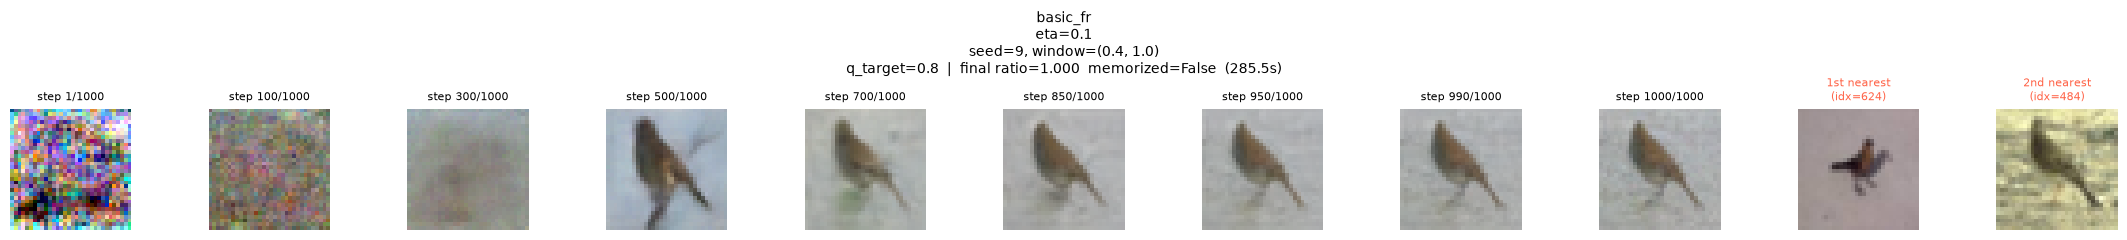

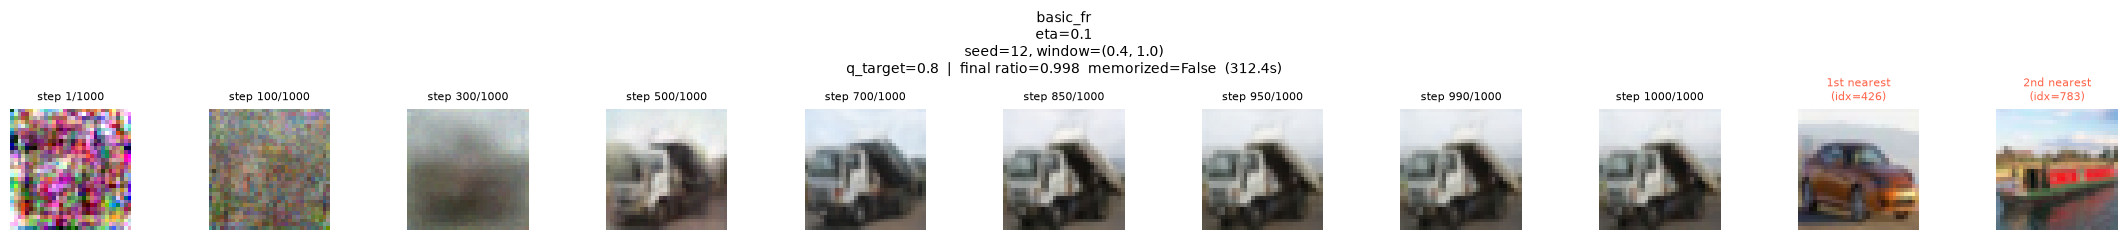

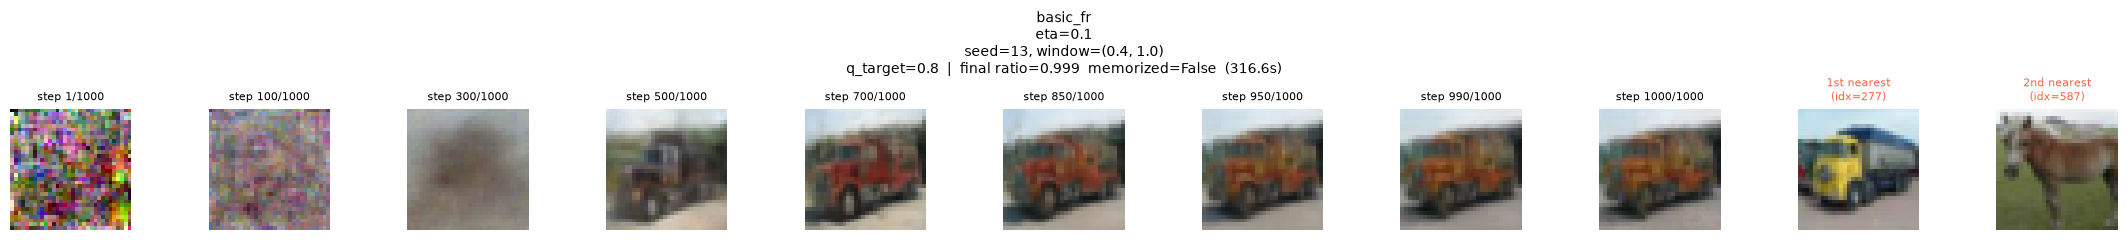

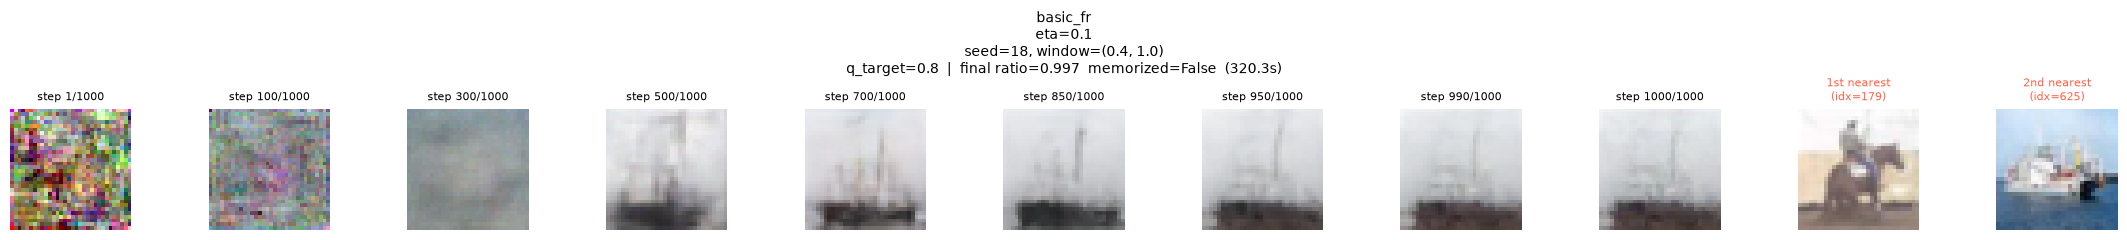

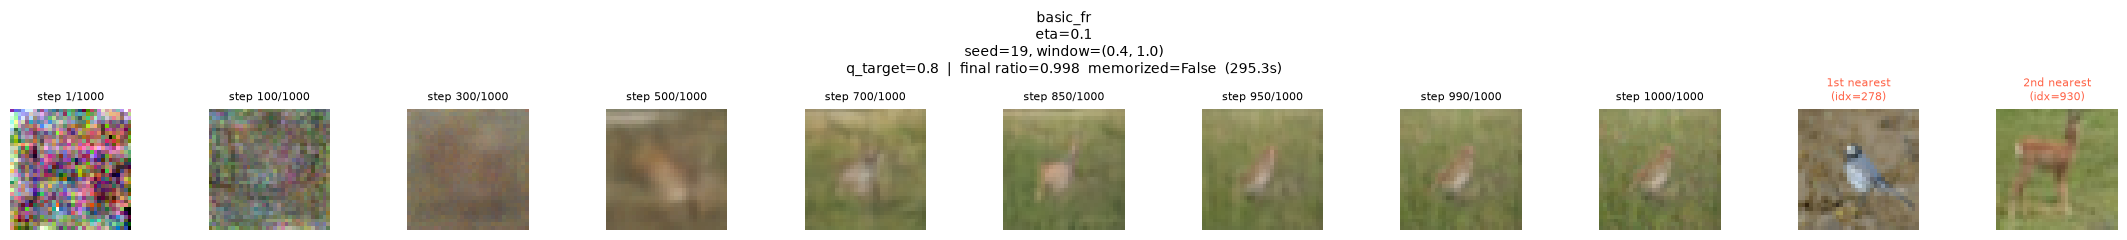

In [ ]:
def panel_label(r):
    repro_tag = f"seed={r.get('seed')}, window={r.get('window')}"
    if r["method"] == "unguided":
        return f"unguided\n{repro_tag}"
    hp_str = ", ".join(f"{k}={v}" for k, v in r["hp"].items())
    return (f"{r['method']}\neta={r.get('eta')}\n{repro_tag}"
            + (f"\n{hp_str}" if hp_str else ""))


def top2_train_indices(x_final):
    d = torch.cdist(pack(x_final), X_train_flat)
    idx = torch.topk(d, 2, dim=1, largest=False).indices[0]
    return int(idx[0]), int(idx[1])


all_results = (baseline_results + results) if baseline else results


for r in all_results:
    select_seed(r["seed"])   # rebinds display_steps / n_steps for THIS result's seed
    steps_sorted = [s for s in display_steps if s in r["hist_out"]]   # hist_out now holds every step; only show the display_fracs checkpoints here
    stats = r["stats"]
    nn_idx1, nn_idx2 = top2_train_indices(r["x_final"])
    assert nn_idx1 == stats["nn_idx"], "recomputed 1st-nearest doesn't match evaluate()'s -- x_final must have changed"
    n_cols = len(steps_sorted) + 2
    fig, axes = plt.subplots(1, n_cols, figsize=(2.0 * n_cols, 2.4))
    for ax, step_idx in zip(axes, steps_sorted):
        y = unpack(r["hist_out"][step_idx])
        ax.imshow(((y[0] + 1) / 2).permute(1, 2, 0).clamp(0, 1))
        ax.set_title(f"step {step_idx}/{r['n_steps']}", fontsize=8)
        ax.axis("off")

    for ax, idx, label in zip(axes[-2:], [nn_idx1, nn_idx2], ["1st nearest", "2nd nearest"]):
        img = X_train[idx]
        ax.imshow(((img.cpu() + 1) / 2).permute(1, 2, 0).clamp(0, 1))
        ax.set_title(f"{label}\n(idx={idx})", fontsize=8, color="tomato")
        ax.axis("off")

    fig.suptitle(f"{panel_label(r)}  |  final ratio={stats['ratio']:.3f}  "
                 f"memorized={stats['is_memorized']}  ({r['runtime_s']:.1f}s)", fontsize=10)
    plt.tight_layout()
    safe_tag = panel_label(r).replace("\n", "_").replace(" ", "").replace(",", "_").replace("=", "")
    plt.savefig(os.path.join(OUT_DIR, f"denoising_{safe_tag}.png"), dpi=150)
    plt.show()

## Sanity check: is the match specific to the 1000-image finetuning subset?

The base checkpoint was pretrained on the full 50k CIFAR-10 split before finetuning on the
1000-image subset. Rechecks each result's nearest neighbor against the full 50k.

seed=9 basic_fr: global nearest neighbor idx=17808 in_finetune_subset=False full-set ratio=0.961  <-- NOT in the 1000-image finetuning subset!


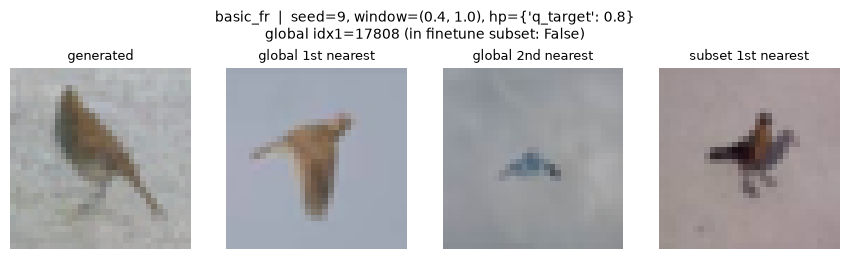

seed=12 basic_fr: global nearest neighbor idx=26112 in_finetune_subset=False full-set ratio=0.971  <-- NOT in the 1000-image finetuning subset!


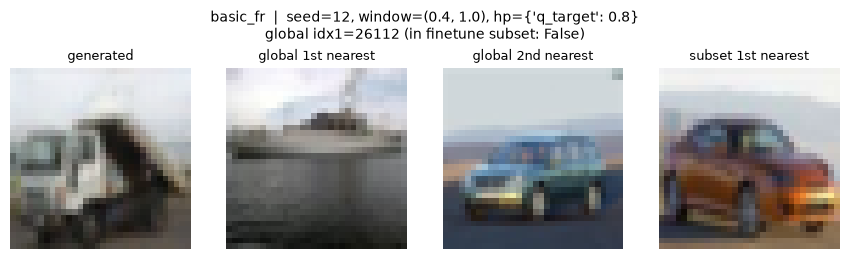

seed=13 basic_fr: global nearest neighbor idx=33568 in_finetune_subset=False full-set ratio=0.962  <-- NOT in the 1000-image finetuning subset!


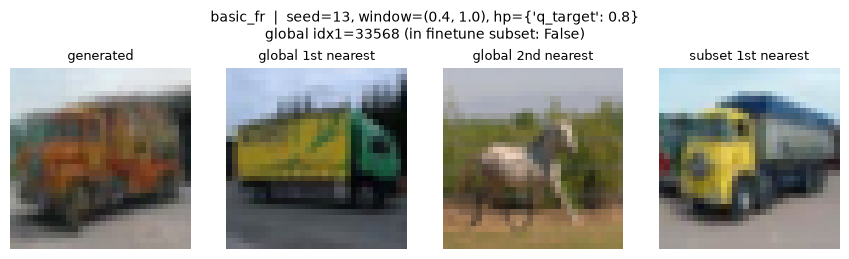

seed=18 basic_fr: global nearest neighbor idx=47409 in_finetune_subset=False full-set ratio=0.958  <-- NOT in the 1000-image finetuning subset!


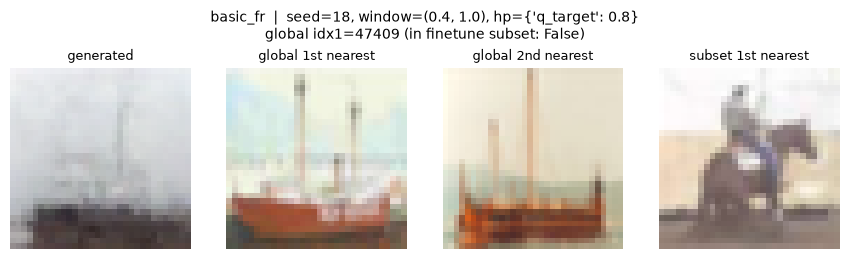

seed=19 basic_fr: global nearest neighbor idx=10155 in_finetune_subset=False full-set ratio=0.979  <-- NOT in the 1000-image finetuning subset!


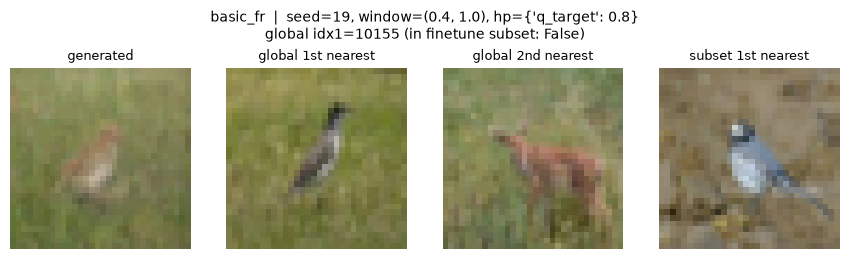

,seed,hp,method,subset_ratio,subset_memorized,full_ratio,in_finetune_subset,global_nn_idx,consistent_with_subset_check
0,9,{'q_target': 0.8},basic_fr,0.999945,False,0.961453,False,17808,False
1,12,{'q_target': 0.8},basic_fr,0.998424,False,0.970665,False,26112,False
2,13,{'q_target': 0.8},basic_fr,0.999308,False,0.962266,False,33568,False
3,18,{'q_target': 0.8},basic_fr,0.996676,False,0.957796,False,47409,False
4,19,{'q_target': 0.8},basic_fr,0.997691,False,0.978854,False,10155,False


In [ ]:
import pandas as pd

images_flat_full = pack(images.to(config["device"]))
train_idx_set = set(train_idx.tolist())


def check_against_full_dataset(x_final):
    d_full = torch.cdist(pack(x_final), images_flat_full)[0]
    top2 = torch.topk(d_full, 2, largest=False)
    idx1_full, idx2_full = int(top2.indices[0]), int(top2.indices[1])
    d1_full, d2_full = top2.values[0].item(), top2.values[1].item()
    return {
        "idx1_full": idx1_full, "idx2_full": idx2_full,
        "d1_full": d1_full, "d2_full": d2_full, "ratio_full": d1_full / d2_full,
        "in_finetune_subset": idx1_full in train_idx_set,
    }


full_check_rows = []
for r in all_results:
    stats = r["stats"]
    full_stats = check_against_full_dataset(r["x_final"])
    subset_nn_as_global_idx = int(train_idx[stats["nn_idx"]])
    consistent = full_stats["idx1_full"] == subset_nn_as_global_idx
    full_check_rows.append({
        "seed": r.get("seed"), "hp": r["hp"],
        "method": r["method"], "subset_ratio": stats["ratio"], "subset_memorized": stats["is_memorized"],
        "full_ratio": full_stats["ratio_full"], "in_finetune_subset": full_stats["in_finetune_subset"],
        "global_nn_idx": full_stats["idx1_full"], "consistent_with_subset_check": consistent,
    })
    flag = "" if full_stats["in_finetune_subset"] else "  <-- NOT in the 1000-image finetuning subset!"
    print(f"seed={r.get('seed')} {r['method']}: global nearest neighbor idx={full_stats['idx1_full']} "
          f"in_finetune_subset={full_stats['in_finetune_subset']} "
          f"full-set ratio={full_stats['ratio_full']:.3f}{flag}")

    repro_tag = f"seed={r.get('seed')}, window={r.get('window')}, hp={r['hp']}"
    panels = [("generated", r["x_final"][0]), ("global 1st nearest", images[full_stats["idx1_full"]]),
              ("global 2nd nearest", images[full_stats["idx2_full"]]),
              ("subset 1st nearest", X_train[stats["nn_idx"]])]
    fig, axes = plt.subplots(1, len(panels), figsize=(2.2 * len(panels), 2.6))
    for ax, (label, img) in zip(axes, panels):
        ax.imshow(((img.cpu() + 1) / 2).permute(1, 2, 0).clamp(0, 1))
        ax.set_title(label, fontsize=9)
        ax.axis("off")
    fig.suptitle(f"{r['method']}  |  {repro_tag}\nglobal idx1={full_stats['idx1_full']} "
                 f"(in finetune subset: {full_stats['in_finetune_subset']})", fontsize=10)
    plt.tight_layout()
    plt.show()

full_check_df = pd.DataFrame(full_check_rows)
full_check_df.to_csv(os.path.join(OUT_DIR, "full_dataset_check.csv"), index=False)
full_check_df

## Summary table + save

In [ ]:
import pandas as pd

summary_rows = [{"seed": r.get("seed"), "method": r["method"], "hp": r["hp"],
                  "q_target": r["hp"].get("q_target"), "eta": r.get("eta"),
                  "window_hi": r.get("window_hi"),
                  "ratio": r["stats"]["ratio"], "memorized": r["stats"]["is_memorized"],
                  "nn_idx": r["stats"]["nn_idx"], "runtime_s": r["runtime_s"]} for r in all_results]
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(os.path.join(OUT_DIR, "fr_guidance_summary.csv"), index=False)
print(summary_df.to_string(index=False))

torch.save({
    "seeds": SEEDS, "window_lo": config["window_lo"], "window_his": as_list(config["window_hi"]),
    "config": config,
    "results": [{"seed": r.get("seed"), "n_steps": r.get("n_steps"), "window": r.get("window"),
                 "method": r["method"], "hp": r["hp"], "eta": r.get("eta"),
                 "x_final": r["x_final"].cpu(), "stats": r["stats"], "runtime_s": r["runtime_s"]}
                for r in all_results],
}, os.path.join(OUT_DIR, "fr_guidance_results.pt"))
print(f"\nsaved to {OUT_DIR}/fr_guidance_results.pt and {OUT_DIR}/fr_guidance_summary.csv")


# one row per CONDITION aggregated over seeds; n_seeds guards a partially-completed sweep
COND_KEYS = ["method", "q_target", "window_hi", "eta"]
agg = (summary_df
       .groupby([k for k in COND_KEYS if summary_df[k].notna().any()], dropna=False)
       .agg(n_seeds=("seed", "nunique"),
            memorized_frac=("memorized", "mean"),
            ratio_mean=("ratio", "mean"),
            ratio_min=("ratio", "min"),
            ratio_max=("ratio", "max"),
            runtime_s=("runtime_s", "sum"))
       .reset_index()
       .sort_values(["memorized_frac", "ratio_mean"], ascending=[True, False]))
agg.to_csv(os.path.join(OUT_DIR, "fr_guidance_by_condition.csv"), index=False)
print("\n=== aggregated over seeds (best conditions first: fewest memorized, then highest d1/d2) ===")
print(agg.to_string(index=False))

pivot = summary_df.pivot_table(index=[k for k in COND_KEYS if summary_df[k].notna().any()],
                                columns="seed", values="ratio", dropna=False)
print("\n=== final d1/d2 by condition (rows) x seed (columns) ===")
print(pivot.to_string())


 seed   method                hp  q_target  eta  window_hi    ratio  memorized  nn_idx  runtime_s
    9 basic_fr {'q_target': 0.8}       0.8  0.1        1.0 0.999945      False     624 285.548450
   12 basic_fr {'q_target': 0.8}       0.8  0.1        1.0 0.998424      False     426 312.381437
   13 basic_fr {'q_target': 0.8}       0.8  0.1        1.0 0.999308      False     277 316.582795
   18 basic_fr {'q_target': 0.8}       0.8  0.1        1.0 0.996676      False     179 320.313771
   19 basic_fr {'q_target': 0.8}       0.8  0.1        1.0 0.997691      False     278 295.260262

saved to checkpoints/fr_guidance_results.pt and checkpoints/fr_guidance_summary.csv

=== aggregated over seeds (best conditions first: fewest memorized, then highest d1/d2) ===
  method  q_target  window_hi  eta  n_seeds  memorized_frac  ratio_mean  ratio_min  ratio_max   runtime_s
basic_fr       0.8        1.0  0.1        5             0.0    0.998409   0.996676   0.999945 1530.086716

=== final d1/d2 by co